# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
!pip install phik
from phik import phik_matrix
!pip install -U scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_recall_curve, auc, classification_report
import joblib
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import average_precision_score, precision_recall_curve


In [3]:
random_state=42

In [4]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep = ",", decimal=".")

## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

In [7]:
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


### Описание данных

Датасет coffee_churn_dataset содержит 10 450 записей о клиентах сервиса доставки кофе Happy Beans Coffee, где каждая строка — это один уникальный пользователь, а 27 колонок описывают его поведение за последние 4 недели: как давно и как часто он заказывал, на какую сумму, какой кофе и с какими предпочтениями покупал, насколько активно пользовался приложением, как оценивал заказы, есть ли у него подписка и включены ли уведомления. Целевая переменная churn показывает, ушёл клиент или остался. Почти все признаки (кроме user_id и churn) содержат пропуски, а сами признаки разнородны: 16 числовых и 10 категориальных.

In [8]:
#Распределение целевой переменной
df['churn'].value_counts(normalize=True)

0    0.939809
1    0.060191
Name: churn, dtype: float64

Целевая переменная несбалансирована: доля ушедших клиентов — 6%, лояльных — 94%

### Описание признаков
user_id — это идентификатор, а не признак, поэтому он удаляется безусловно, так как не имеет предсказательной силы. Остальные признаки будут оценены в ходе дальнейшей работы.

Не все признаки важны. Важные — те, что показывают поведение и вовлечённость: давность заказа, активность в приложении, оценки, подписка, скидки, уведомления, сбои, смена вкусов и траты. **Под вопросом** — частота заказов за месяц, медианный чек, сезон, регион, тип телефона и вкусовые предпочтения: возможно, дублируют или шумят. Точно лишний — user_id, это просто ID. Вывод: не все, окончательно решаем после корреляций.

In [9]:
#Пропуски
df.isna().sum()

user_id                       0
days_since_last_order       945
order_frequency_month       600
order_frequency_week        388
avg_order_value             583
median_order_value          831
total_spent_last_month      294
total_spent_last_week       944
discount_usage_rate         397
last_coffee_type            258
preferred_roast             116
milk_preference             668
seasonal_menu_tried         989
coffee_bean_origin          682
last_drink_size             504
subscription_status         938
app_opens_per_week          896
notifications_enabled       537
review_rating_last_10       693
review_rating_last_1        857
app_crashes_last_month      721
seasons                     679
days_since_last_promo       731
phone_type                  336
coffee_preference_change    610
geo_location                110
churn                         0
dtype: int64

### Вывод по пропускам

Пропуски есть почти во всех признаках (кроме user_id и churn) и составляют 6–9% значений, что делает удаление строк неприемлемым — это потеряло бы почти половину клиентов. LogisticRegression не работает с NaN, поэтому пропуски нужно заполнять. Для числовых признаков используется медиана (SimpleImputer(strategy='median')) — она устойчива к выбросам в чеках и тратах; для категориальных — мода (strategy='most_frequent'). Все преобразования выполняются внутри Pipeline, чтобы избежать утечки данных из теста в обучение.

### Анализ категориальных признаков
Кодировать нужно категориальные признаки (object), потому что LogisticRegression работает только с числами. Их 10: last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, last_drink_size
subscription_status, seasons, phone_type, geo_location (user_id — не кодируем, удаляем)


Почему? Модель не понимает строки. Категории нужно превратить в числа. Для нашего случая, я думаю, лучше OneHotEncoder — он не создаёт ложного порядка между категориями.


Да, генерация новых признаков возможна. Возможные стратегии: 

1. Отношения

2. Разность

3. Показатели вовлечённости

4. Логарифмирование

5. Возведение в степени

Безусловно удаляется только user_id — это идентификатор, а не признак. Остальные кандидаты требуют проверки: order_frequency_month и median_order_value — при высокой корреляции с парными признаками; seasons — если окажется константой; geo_location и phone_type — при слабой связи с churn; вкусовые предпочтения — при mutual_info ≈ 0. Окончательное решение — только после корреляционного анализа, проверки, чтобы не удалить случайно полезный признак.

In [10]:
df = df.drop(columns = 'user_id')

In [11]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


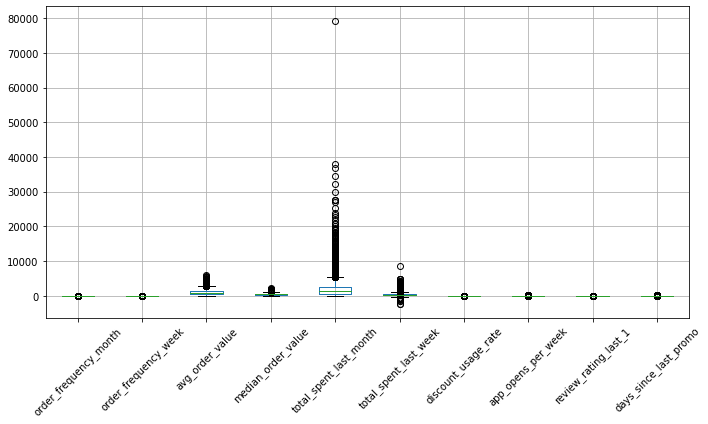

In [12]:
#Боксплоты
plt.figure(figsize=(10, 6))
df[['order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month' , 'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_1', 'days_since_last_promo']].boxplot(rot=45, grid=True, fontsize=10)
plt.tight_layout()
plt.show()

count    10062.000000
mean         0.930686
std          0.657261
min         -0.169131
25%          0.445185
50%          0.784839
75%          1.262350
max          6.302624
Name: order_frequency_week, dtype: float64
 Количество строк <0:83


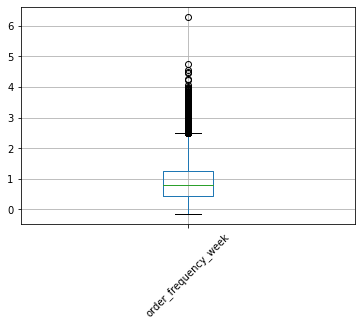

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
9,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,light,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0
191,2.0,0.199242,-0.169131,3710.492841,1131.554717,257.097416,-237.899451,0.115694,arabica,light,...,0.0,5.132989,3.098811,2.0,winter,17.0,android,1.0,geo_15,0
345,2.0,1.132874,-0.074783,715.372314,207.050397,238.475342,-11.382833,0.365909,robusta,light,...,1.0,4.073474,2.330635,2.0,summer,NaN,android,0.0,geo_21,0
459,NaN,0.137639,-0.115005,1737.175104,588.750337,95.868242,-63.307077,0.094216,arabica,dark,...,NaN,3.885550,3.784214,3.0,autumn,18.0,ios,0.0,geo_2,0
580,0.0,0.952046,-0.086405,863.575082,389.795343,349.746332,-38.038551,0.452252,arabica,dark,...,1.0,5.308735,3.386282,0.0,autumn,27.0,ios,0.0,geo_99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9800,1.0,0.706231,-0.024641,1450.113596,514.035173,397.083955,-12.154226,0.078173,arabica,light,...,NaN,3.356853,3.993260,0.0,spring,51.0,android,0.0,geo_2,0
9811,6.0,0.545328,-0.068773,1711.945547,591.417314,366.842403,-44.948996,0.141739,blend,light,...,0.0,NaN,5.395311,1.0,spring,46.0,android,0.0,geo_10,0
9880,0.0,0.255497,-0.000350,2524.486305,900.345666,262.161500,-0.377899,0.098864,arabica,medium,...,1.0,3.971364,4.913080,0.0,spring,13.0,android,1.0,geo_21,0
10276,5.0,0.344994,-0.086736,1096.365813,460.575947,175.726601,NaN,0.091049,robusta,dark,...,1.0,3.258901,6.152673,0.0,winter,6.0,android,0.0,geo_3,0


In [13]:
#Информация order_frequency_week
print(df['order_frequency_week'].describe())
print(f" Количество строк <0:{df[df['order_frequency_week']<0].shape[0]}")
df['order_frequency_week'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()
ex = df[df['order_frequency_week']<0]
ex

count    9867.000000
mean     1063.741207
std       707.713396
min       -32.075932
25%       552.898663
50%       898.643524
75%      1406.332153
max      5901.965278
Name: avg_order_value, dtype: float64
 Количество строк <0:2


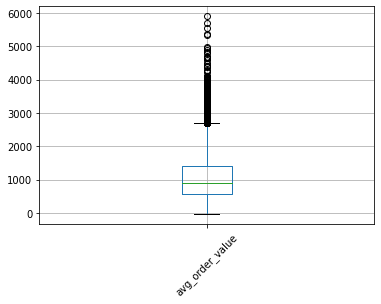

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
8176,0.0,3.839381,1.043652,-32.075932,-10.353340,-43.716463,-11.723440,0.500261,arabica,light,...,1.0,5.113545,5.153962,0.0,winter,20.0,NaN,0.0,geo_1,0
9233,6.0,2.220828,0.689320,-24.970131,-7.325263,-14.737615,-3.650004,0.101484,robusta,dark,...,1.0,3.720842,2.738778,1.0,winter,1.0,web,0.0,geo_96,0


In [14]:
#Информация avg_order_value
print(df['avg_order_value'].describe())
print(f" Количество строк <0:{df[df['avg_order_value']<0].shape[0]}")
df['avg_order_value'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()
ex = df[df['avg_order_value']<0]
ex

count    9619.000000
mean      452.651500
std       258.657571
min       -10.353340
25%       262.908598
50%       406.456818
75%       590.418070
max      2189.101644
Name: median_order_value, dtype: float64
 Количество строк <0:2


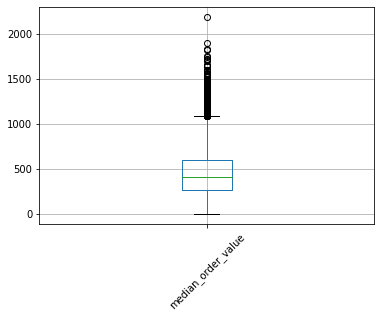

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
8176,0.0,3.839381,1.043652,-32.075932,-10.353340,-43.716463,-11.723440,0.500261,arabica,light,...,1.0,5.113545,5.153962,0.0,winter,20.0,NaN,0.0,geo_1,0
9233,6.0,2.220828,0.689320,-24.970131,-7.325263,-14.737615,-3.650004,0.101484,robusta,dark,...,1.0,3.720842,2.738778,1.0,winter,1.0,web,0.0,geo_96,0


In [15]:
#Информация median_order_value
print(df['median_order_value'].describe())
print(f" Количество строк <0:{df[df['median_order_value']<0].shape[0]}")
df['median_order_value'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()
ex = df[df['median_order_value']<0]
ex

count    10156.000000
mean      1946.132979
std       2370.619590
min        -43.716463
25%        629.680382
50%       1300.409757
75%       2481.650495
max      79298.849570
Name: total_spent_last_month, dtype: float64
 Количество строк <0:2


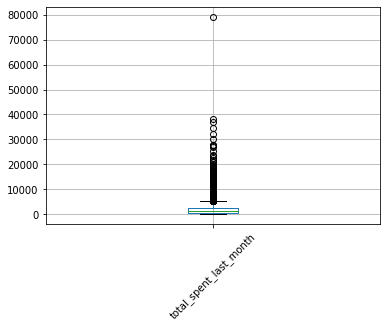

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
8176,0.0,3.839381,1.043652,-32.075932,-10.353340,-43.716463,-11.723440,0.500261,arabica,light,...,1.0,5.113545,5.153962,0.0,winter,20.0,NaN,0.0,geo_1,0
9233,6.0,2.220828,0.689320,-24.970131,-7.325263,-14.737615,-3.650004,0.101484,robusta,dark,...,1.0,3.720842,2.738778,1.0,winter,1.0,web,0.0,geo_96,0


In [16]:
#Информация total_spent_last_month
print(df['total_spent_last_month'].describe())
print(f" Количество строк <0:{df[df['total_spent_last_month']<0].shape[0]}")
df['total_spent_last_month'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()
ex = df[df['total_spent_last_month']<0]
ex

count    9506.000000
mean      413.004760
std       445.634902
min     -2290.559468
25%       136.565833
50%       288.277327
75%       549.699420
max      8615.988952
Name: total_spent_last_week, dtype: float64
 Количество строк <0:171


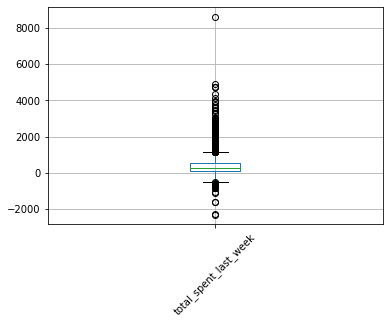

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
9,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,light,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0
188,3.0,5.019632,1.195954,1546.929497,654.213227,3057.644199,-646.719093,0.055872,arabica,dark,...,0.0,5.249486,5.151920,1.0,winter,NaN,android,1.0,geo_36,0
191,2.0,0.199242,-0.169131,3710.492841,1131.554717,257.097416,-237.899451,0.115694,arabica,light,...,0.0,5.132989,3.098811,2.0,winter,17.0,android,1.0,geo_15,0
193,24.0,2.542895,0.567124,1342.726233,522.184855,1202.395592,-344.924273,0.223425,NaN,light,...,NaN,5.147882,3.638431,2.0,autumn,6.0,android,1.0,geo_76,0
345,2.0,1.132874,-0.074783,715.372314,207.050397,238.475342,-11.382833,0.365909,robusta,light,...,1.0,4.073474,2.330635,2.0,summer,NaN,android,0.0,geo_21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10003,5.0,3.725641,0.830454,789.809037,348.703243,1316.261165,-271.359227,0.330724,arabica,dark,...,1.0,5.042044,3.491948,2.0,autumn,NaN,android,0.0,geo_3,0
10024,2.0,3.602486,NaN,2359.212558,976.439233,4195.609969,-755.346750,0.373559,arabica,dark,...,1.0,3.907031,NaN,4.0,winter,NaN,ios,1.0,geo_1,1
10025,3.0,1.082639,0.444744,2719.829894,853.413174,806.005470,-334.023706,0.420309,robusta,medium,...,0.0,5.767336,4.913093,1.0,autumn,7.0,android,0.0,geo_3,0
10248,5.0,2.237541,0.380135,2496.586366,763.513805,1816.992342,-275.571784,0.359006,blend,medium,...,0.0,3.144985,5.549957,2.0,autumn,34.0,ios,0.0,geo_2,0


In [17]:
#Информация total_spent_last_week
print(df['total_spent_last_week'].describe())
print(f" Количество строк <0:{df[df['total_spent_last_week']<0].shape[0]}")
df['total_spent_last_week'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()
ex = df[df['total_spent_last_week']<0]
ex

count    9554.000000
mean       11.330895
std        14.528887
min         0.000000
25%         6.313628
50%         9.228383
75%        12.726649
max       224.587876
Name: app_opens_per_week, dtype: float64


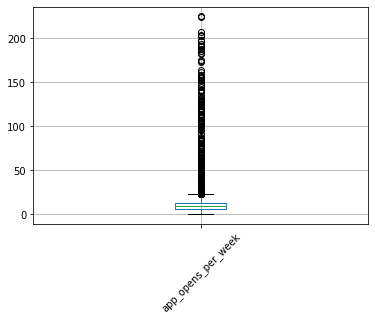

In [18]:
#Информация app_opens_per_week
print(df['app_opens_per_week'].describe())
df['app_opens_per_week'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()


count    9593.000000
mean        4.022460
std         1.207883
min        -0.897000
25%         3.214157
50%         3.990032
75%         4.845225
max         8.558443
Name: review_rating_last_1, dtype: float64
 Количество строк <0:6


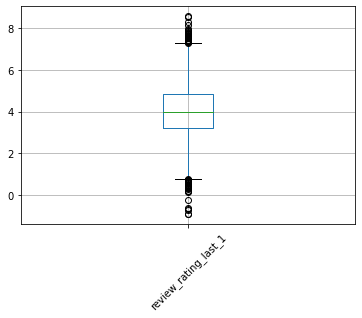

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
3569,16.0,2.378596,0.517216,2207.281887,975.471749,2086.681417,400.474680,0.219084,blend,medium,...,0.0,4.194786,-0.654883,2.0,winter,24.0,android,1.0,geo_3,0
4626,0.0,1.300067,0.373419,1132.874251,562.879198,689.480395,262.098168,0.223964,arabica,medium,...,0.0,4.191055,-0.733524,2.0,winter,NaN,android,0.0,geo_48,0
8044,2.0,3.410534,0.899947,250.475303,157.230102,627.714176,170.931623,0.508307,arabica,medium,...,0.0,4.490215,-0.897000,0.0,autumn,29.0,android,0.0,geo_1,0
8125,2.0,1.376997,0.345475,NaN,716.698307,1056.574986,304.503909,0.077841,robusta,dark,...,0.0,4.042738,-0.241400,3.0,NaN,21.0,android,0.0,geo_3,0
9150,2.0,3.410534,0.899947,250.475303,157.230102,627.714176,170.931623,0.508307,arabica,medium,...,0.0,4.490215,-0.897000,0.0,autumn,29.0,android,0.0,geo_1,0
10214,0.0,1.644295,0.317848,2191.189511,684.812163,963.226205,264.811915,0.309546,arabica,dark,...,1.0,4.496728,-0.624688,2.0,summer,35.0,ios,0.0,geo_2,0


In [19]:
#Информация review_rating_last_1
print(df['review_rating_last_1'].describe())
print(f" Количество строк <0:{df[df['review_rating_last_1']<0].shape[0]}")
df['review_rating_last_1'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()
ex = df[df['review_rating_last_1']<0]
ex

In [20]:
#Исправление нулевых оценок
df['review_rating_last_1'] = df['review_rating_last_1'].clip(lower=0)
df['review_rating_last_10'] = df['review_rating_last_10'].clip(lower=0)

count    9729.000000
mean        1.013362
std         1.010342
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: app_crashes_last_month, dtype: float64


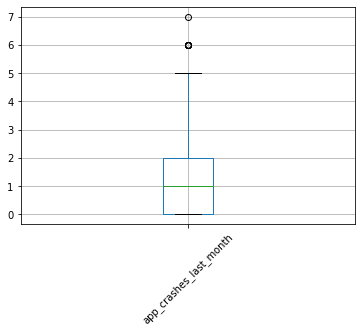

count    9719.000000
mean       14.554584
std        15.308869
min         0.000000
25%         4.000000
50%        10.000000
75%        20.000000
max       140.000000
Name: days_since_last_promo, dtype: float64


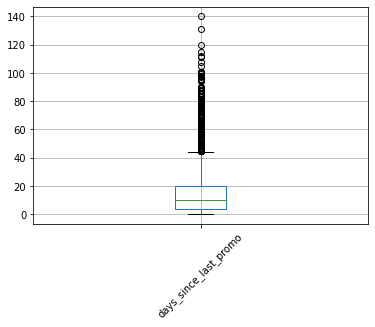

In [21]:
#Информация review_rating_last_1
print(df['app_crashes_last_month'].describe())
df['app_crashes_last_month'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()
print(df['days_since_last_promo'].describe())
df['days_since_last_promo'].plot.box(rot=45, grid=True, fontsize=10)
plt.show()

### Вывод по выбросам

В датасете присутствуют выбросы нескольких типов, и большинство из них не являются ошибками. Отрицательные значения в тратах (total_spent_last_month = −43.7, total_spent_last_week = −2290.6, avg_order_value = −32.1, median_order_value = −10.4) объясняются возвратами, превысившими покупки за период: по недельным тратам таких клиентов 171 (1.6%), по остальным признакам — всего 2 записи (одни и те же user_01422 и user_07617), это выбросы. Признак order_frequency_week (83 отрицательных значения) — динамика частоты заказов, поэтому минус здесь осмыслен. Признак review_rating_last_1 использует шкалу 0–10, и единственная настоящая аномалия — 6 значений ниже нуля (min = −0.897), что для оценки невозможно; их следует заменить на 0. Отдельно выделяются правые хвосты: total_spent_last_month max = 79298 при медиане 1300, total_spent_last_week max = 8616 при медиане 288, app_opens_per_week max = 224 при медиане 9, days_since_last_promo max = 140 при медиане 10 — это «сверхактивные» клиенты, а не ошибки, но они сильно искажают распределение. Главное следствие: StandardScaler не подходит из-за чувствительности к выбросам — нужен RobustScaler (медиана и IQR); отрицательные траты можно оставить как сигнал возвратов.

In [22]:
df.corr(method='spearman')

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
days_since_last_order,1.000000,-0.001184,-0.007814,-0.002650,0.001321,0.000979,0.001211,0.017455,0.011980,-0.022225,-0.015072,-0.004384,0.003101,-0.003188,-0.006218,-0.014759,-0.008290
order_frequency_month,-0.001184,1.000000,0.980571,-0.007740,-0.002790,0.736853,0.720638,-0.025456,0.016882,0.429270,0.012697,-0.000937,-0.001276,-0.019644,0.012462,0.000210,0.060196
order_frequency_week,-0.007814,0.980571,1.000000,-0.003688,0.000228,0.721934,0.736587,-0.022660,0.011874,0.439994,0.005824,0.002419,0.003750,-0.016212,0.013567,0.006016,0.062504
avg_order_value,-0.002650,-0.007740,-0.003688,1.000000,0.879768,0.518655,0.505933,-0.008790,-0.002360,-0.001691,0.000030,-0.005215,-0.000506,-0.004794,-0.008935,-0.000773,-0.015031
median_order_value,0.001321,-0.002790,0.000228,0.879768,1.000000,0.585275,0.569628,-0.016729,-0.003491,0.004855,-0.001215,0.001656,0.008299,0.001098,-0.016630,0.001066,-0.001105
total_spent_last_month,0.000979,0.736853,0.721934,0.518655,0.585275,1.000000,0.918070,-0.022313,0.003117,0.367826,0.007474,0.003363,0.002419,-0.020859,-0.000025,0.003967,0.040341
total_spent_last_week,0.001211,0.720638,0.736587,0.505933,0.569628,0.918070,1.000000,-0.023335,0.011240,0.318225,0.009213,-0.001086,-0.004867,-0.021674,-0.002576,0.006643,0.043538
discount_usage_rate,0.017455,-0.025456,-0.022660,-0.008790,-0.016729,-0.022313,-0.023335,1.000000,-0.001322,-0.014682,-0.003321,-0.008891,-0.002600,-0.008012,-0.007883,-0.002570,-0.009789
seasonal_menu_tried,0.011980,0.016882,0.011874,-0.002360,-0.003491,0.003117,0.011240,-0.001322,1.000000,0.010071,0.022822,-0.010410,0.015497,0.009906,0.004167,-0.005294,-0.006234
app_opens_per_week,-0.022225,0.429270,0.439994,-0.001691,0.004855,0.367826,0.318225,-0.014682,0.010071,1.000000,-0.004572,0.000103,-0.000997,-0.004817,-0.000878,-0.001631,0.126020


In [23]:
df.corr(method='pearson')

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
days_since_last_order,1.000000,-0.003549,-0.006873,0.005814,0.010403,0.001865,0.004685,0.019063,0.007890,-0.022419,-0.021411,-0.001173,-0.004432,-0.015911,-0.002910,-0.004170,-0.011126
order_frequency_month,-0.003549,1.000000,0.988474,-0.011896,-0.002070,0.559352,0.649804,-0.022684,0.005075,0.177544,0.008425,0.009963,0.006585,-0.023971,0.011974,0.001007,0.074891
order_frequency_week,-0.006873,0.988474,1.000000,-0.008607,0.000820,0.555479,0.657581,-0.020210,0.000268,0.177654,0.002160,0.011447,0.007228,-0.023404,0.014409,0.005928,0.073168
avg_order_value,0.005814,-0.011896,-0.008607,1.000000,0.868503,0.398330,0.450275,-0.001878,-0.002034,-0.014801,-0.002756,-0.001324,0.004574,-0.008100,-0.004854,-0.004657,-0.009141
median_order_value,0.010403,-0.002070,0.000820,0.868503,1.000000,0.459456,0.538515,-0.015123,-0.000736,-0.011158,-0.006645,0.005004,0.008707,0.000664,-0.013532,-0.003325,-0.000433
total_spent_last_month,0.001865,0.559352,0.555479,0.398330,0.459456,1.000000,0.745806,-0.017471,-0.001654,0.426122,-0.009297,0.011186,0.009534,-0.021943,-0.014272,-0.005402,0.033813
total_spent_last_week,0.004685,0.649804,0.657581,0.450275,0.538515,0.745806,1.000000,-0.019624,0.000285,0.100960,0.000206,0.016624,-0.001993,-0.019440,-0.001434,-0.005388,0.050334
discount_usage_rate,0.019063,-0.022684,-0.020210,-0.001878,-0.015123,-0.017471,-0.019624,1.000000,-0.002934,-0.005913,-0.001982,-0.009788,0.000804,-0.008483,-0.009148,-0.000480,-0.006709
seasonal_menu_tried,0.007890,0.005075,0.000268,-0.002034,-0.000736,-0.001654,0.000285,-0.002934,1.000000,-0.003330,0.022822,-0.007130,0.014248,0.012549,0.010144,-0.005294,-0.006234
app_opens_per_week,-0.022419,0.177544,0.177654,-0.014801,-0.011158,0.426122,0.100960,-0.005913,-0.003330,1.000000,-0.004925,-0.007585,0.007758,-0.010413,-0.026228,-0.006302,0.056603


In [24]:
#Удаления из-за мультикорреляции
drop_duplicates = [         
    'order_frequency_month',   
    'median_order_value',      
    'total_spent_last_week'
]

df = df.drop(columns=drop_duplicates)


In [25]:
df.duplicated().sum()

414

In [26]:
#Удаление дубликатов
df = df.drop_duplicates()

### Вывод по корреляции
На этапе анализа корреляций между признаками мы посчитали матрицы Пирсона и Спирмена и нашли четыре дубликата: total_spent_last_month и log_total_spent (Спирмен = 1.000), order_frequency_month и order_frequency_week (0.981 — одно и то же в разных единицах), avg_order_value и median_order_value (0.880 — оба про «типичный чек») и total_spent_last_month и total_spent_last_week (0.918 — связаны через 4 недели). Удалили по одному из каждой пары: log_total_spent, order_frequency_month, median_order_value, total_spent_last_week. rating_delta, engagement_score не трогали — они связаны с исходными признаками (0.83 и 0.80), но несут дополнительный сигнал. 

По результатам исследовательского анализа данных можно сказать следующее. Датасет содержит 10 450 клиентов и 27 колонок. Признаки описывают поведение заказов, предпочтения в кофе, вовлечённость в приложение, отзывы и прочие характеристики. Целевая переменная churn сильно несбалансирована: около 94 процентов клиентов остаются и лишь 6 процентов уходят. Пропуски присутствуют почти во всех признаках, кроме user_id и churn, и составляют от 6 до 9 процентов значений, поэтому удаление строк неприемлемо и нужна работа по ним внутри пайплайна, медиана для числовых и мода для категориальных. Признаки разнородны: 16 числовых и 10 категориальных, с разными масштабами, что требует раздельной обработки через ColumnTransformer. Распределения числовых признаков имеют сильные правые хвосты: total_spent_last_month достигает 79 298 при медиане 1 300, app_opens_per_week — 224 при медиане 9, days_since_last_promo — 140 при медиане 10, поэтому StandardScaler не подходит из-за чувствительности к выбросам и нужен RobustScaler. Обнаружены отрицательные значения в тратах и оценках: они объясняются возвратами и и преобразованиями, это не ошибка датасета, но 6 отрицательных значений review_rating_last_1 при шкале от 0 до 10 — аномалия, которую стоит заменить на 0. Анализ корреляций между признаками выявил четыре дубликата: total_spent_last_month и log_total_spent со Спирменом 1.000, order_frequency_month и order_frequency_week с 0.981, avg_order_value и median_order_value с 0.880 по Пирсону, total_spent_last_month и total_spent_last_week с 0.918, поэтому были удалены order_frequency_month, median_order_value и total_spent_last_week. Таким образом, данные готовы к предобработке и обучению модели.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [27]:
#Разделение признаков и целевой переменной
X = df.drop (columns = 'churn')
y = df['churn']

In [28]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

In [29]:
#Выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,     
    stratify=y           
)

In [30]:
scaler = RobustScaler()
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')
imputer = SimpleImputer(strategy='median')
impeter_cat = SimpleImputer(strategy='most_frequent')

In [31]:
#Для числовых
pipeline_num = Pipeline([
    ('imputer', imputer),
    ('scaler', scaler)         
])

In [32]:
#Для категориальных
pipeline_cat = Pipeline([
    ('imputer', impeter_cat),
    ('one_hot_encoder', one_hot_encoder)
])

In [33]:
preprocessor = ColumnTransformer([
    ('num', pipeline_num, num_cols),
    ('cat', pipeline_cat, cat_cols)
])

Данные были разделены в пропорции 80 к 20. Был создан пайплайн, который обработает пропуски и выбросы, пайплайн, который обработает категориальные признаки, пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию. Они были объудинены в preprocessor


## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [34]:
#Дамми
dummy = DummyClassifier(strategy='most_frequent', random_state=42)

In [35]:
#Логистическая
logist = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=1.0)

In [36]:
#Создание фунцкции
def build_pipeline(num_cols, cat_cols):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    pre = ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])
    return Pipeline([
        ('preprocessing', pre),
        ('classifier', LogisticRegression(
            class_weight='balanced', random_state=42, max_iter=1000
        ))
    ])

In [37]:
#Пайплайн для дамми
pipeline_log = Pipeline(steps=[
    ('preprocessing', preprocessor), 
    ('classifier', logist)            
])

In [38]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [39]:
#Кросс для логистической
results_log1 = cross_validate(
    estimator=pipeline_log,           
    X=X_train,                          
    y=y_train,                          
    scoring=['average_precision', 'precision', 'recall', 'f1'],   
    cv=cv,                        
    return_train_score = True,    
    return_estimator = True,      
    n_jobs=-1                     
)

In [40]:
#Пайплайн для дамми
pipeline_d = Pipeline(steps=[
    ('preprocessing', preprocessor), 
    ('classifier', dummy)            
])

In [41]:
#Кросс для Дамми
results_d = cross_validate(
    estimator=pipeline_d,          
    X=X_train,                          
    y=y_train,                          
    scoring=['average_precision', 'precision', 'recall', 'f1'],   
    cv=cv,                        
    return_train_score = True,    
    return_estimator = True,      
    n_jobs=-1                     
)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:15

In [42]:
#Результаты Дамми
for m in ['average_precision', 'precision', 'recall', 'f1']:
    print(f"{m} = {results_d[f'test_{m}'].mean():.4f}")

average_precision = 0.0600
precision = 0.0000
recall = 0.0000
f1 = 0.0000


In [43]:
#Результаты логистической
for m in ['average_precision', 'precision', 'recall', 'f1']:
    print(f"{m} = {results_log1[f'test_{m}'].mean():.4f}")

average_precision = 0.5810
precision = 0.2878
recall = 0.8359
f1 = 0.4275


Для базовой версии модели использованы две простые статистические модели: DummyClassifier со стратегией most_frequent и LogisticRegression с class_weight balanced, random_state 42, max_iter 1000 и C 1.0. Обе модели обучены через кросс-валидацию StratifiedKFold с 10 фолдами, shuffle True и random_state 42 на обучающей выборке X_train, что при дисбалансе классов 94 на 6 сохраняет пропорцию в каждом фолде и даёт устойчивую оценку. Посчитаны метрики average_precision, precision, recall и f1. DummyClassifier показал average_precision 0.06, precision 0, recall 0 и f1 0. LogisticRegression показала average_precision 0.58, precision 0.2878, recall 0.8359 и f1 0.4275. Это значит, что модель реально учится и значительно превосходит случайную: PR AUC в девять с половиной раз выше базового уровня. Precision невысок, но при дисбалансе 94 на 6 и это ожидаемо, и основная метрика PR AUC здесь важнее. Вывод: базовая логистическая регрессия показала хорошее качество для стартовой модели и модель можно использовать как ориентир для дальнейших улучшений через новые признаки и подбор гиперпараметров.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [44]:
#Добавление новых признаков
df["sqrt_total_spent_last_month"] = np.sqrt(df["total_spent_last_month"].clip(lower=0)) 
df["sqrt_app_opens_per_week"] = np.sqrt(df["app_opens_per_week"]) 
df["sqrt_days_since_last_promo"] = np.sqrt(df["days_since_last_promo"])
df["app_crashes_last_month_squared"] = df["app_crashes_last_month"] ** 2
df['activity'] = df['days_since_last_order'] * df['order_frequency_week']

In [45]:
X = df.drop(columns=['churn'])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,     
    stratify=y           
)

In [47]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

In [48]:
#Новый пайплайн
pipeline_log = build_pipeline(num_cols, cat_cols)

In [49]:
#Кросс-валидация
results1 = cross_validate(
    estimator=pipeline_log,           
    X=X_train,                         
    y=y_train,                          
    scoring=['average_precision', 'precision', 'recall', 'f1'],   
    cv=cv,                       
    return_train_score = True,   
    return_estimator = True,      
    n_jobs=-1                     
)

In [50]:
#Результаты
for m in ['average_precision', 'precision', 'recall', 'f1']:
    print(f"{m} = {results1[f'test_{m}'].mean():.4f}")

average_precision = 0.6600
precision = 0.3366
recall = 0.8318
f1 = 0.4782


In [51]:
#Коэффициенты
pipeline_log.fit(X_train, y_train)
model = pipeline_log.named_steps['classifier']
pre   = pipeline_log.named_steps['preprocessing']
names = pre.get_feature_names_out()

importance = pd.Series(model.coef_[0], index=names).sort_values()

print(importance.to_string()) 

importance_abs = importance.abs().sort_values(ascending=False)
print(importance.reindex(importance_abs.index).to_string())

cat__geo_location_geo_89              -1.568977
cat__geo_location_geo_78              -1.537983
cat__geo_location_geo_9               -1.501503
cat__geo_location_geo_8               -1.495552
cat__geo_location_geo_41              -1.492251
cat__geo_location_geo_88              -1.465386
cat__geo_location_geo_23              -1.456689
cat__geo_location_geo_57              -1.425322
cat__geo_location_geo_14              -1.420789
cat__geo_location_geo_87              -1.328678
cat__geo_location_geo_36              -1.294101
cat__geo_location_geo_40              -1.219792
cat__geo_location_geo_52              -1.173569
cat__geo_location_geo_17              -1.095853
cat__geo_location_geo_46              -1.089114
cat__geo_location_geo_53              -1.051321
cat__geo_location_geo_32              -1.009128
cat__geo_location_geo_12              -0.999979
cat__geo_location_geo_58              -0.996430
cat__geo_location_geo_37              -0.983380
cat__geo_location_geo_69              -0

In [52]:
#Оценка новых признаков
new_features = [
    'num__sqrt_total_spent_last_month',
    'num__sqrt_app_opens_per_week',
    'num__sqrt_days_since_last_promo',
    'num__app_crashes_last_month_squared',
    'num__activity'
]

new_importance = importance[importance.index.isin(new_features)]
print(new_importance.sort_values())

num__sqrt_total_spent_last_month      -0.487784
num__activity                          0.025048
num__sqrt_days_since_last_promo        0.553841
num__sqrt_app_opens_per_week           1.709165
num__app_crashes_last_month_squared    2.024455
dtype: float64


In [53]:
#Удаление
df = df.drop(columns = [
    'seasons',
    'days_since_last_order',
    'activity',   
    'total_spent_last_month',
    'geo_location',
    'notifications_enabled',
    'coffee_preference_change',
    'discount_usage_rate',
    'review_rating_last_1'])

In [54]:
X = df.drop(columns=['churn'])

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,     
    stratify=y           
)

In [56]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

In [57]:
#Новый пайплайн
pipeline_log = build_pipeline(num_cols, cat_cols)

In [58]:
#Кросс
results2 = cross_validate(
    estimator=pipeline_log,           
    X=X_train,                          
    y=y_train,                        
    scoring=['average_precision', 'precision', 'recall', 'f1'],  
    cv=cv,                        
    return_train_score = True,    
    return_estimator = True,      
    n_jobs=-1                     
)

In [59]:
#Результаты
for m in ['average_precision', 'precision', 'recall', 'f1']:
    print(f"{m} = {results2[f'test_{m}'].mean():.4f}")

average_precision = 0.6986
precision = 0.3335
recall = 0.8484
f1 = 0.4780


Были созданы пять новых признаков: sqrt_total_spent_last_month и sqrt_days_since_last_promo через извлечение квадратного корня для сглаживания больших значений, sqrt_app_opens_per_week тоже через корень, app_crashes_last_month_squared через возведение в квадрат для усиления влияния больших значений, и activity как произведение days_since_last_order на order_frequency_week. Пайплайн build_pipeline(num_cols, cat_cols) обновлён под новые признаки. Повторная кросс-валидация показала average_precision 0.66, precision 0.3366, recall 0.8318, f1 0.4782 — это заметно лучше базовой версии. Интерпретация коэффициентов показала, что сильнее всего к оттоку толкают num_app_crashes_last_month_squared с коэффициентом около 2.03, num_sqrt_app_opens_per_week с 1.79 и num_sqrt_days_since_last_promo с 0.57, а удерживает num_sqrt_total_spent_last_month с минус 0.48. Признак num_activity дал всего 0.03 — почти ноль, поэтому он неинформативен и его можно удалить. На основе анализа также удалены слабые признаки: 'seasons', 'days_since_last_order','activity', 'total_spent_last_month', 'geo_location', 'notifications_enabled', 'coffee_preference_change', 'discount_usage_rate','review_rating_last_1', причём geo_location удалён из-за высокой кардинальности и отсутствия прироста, а остальные как слабые или дублирующие. После удаления и пересборки пайплайна финальная модель показала average_precision около 0.70.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

In [60]:
#Подбор через GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C':            [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__penalty':      ['l1', 'l2'],
    'classifier__solver':       ['liblinear', 'saga'],
    'classifier__class_weight': [None, 'balanced'],
}
grid_search = GridSearchCV(
    estimator=pipeline_log,                        
    param_grid=param_grid,
    scoring='average_precision',                  
    cv=cv,                                         
    n_jobs=-1,
    refit=True,                                    
    return_train_score=True,                       
    
)
grid_search.fit(X_train, y_train)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means 

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['order_frequency_week',
                                                                          'avg_order_value',
                                                                          'seasonal_menu_tried',
                                                                          'app_opens_per_week',
                                                                          'review_rating_last_...
                                                                          'subscription_status',
                                                                          'phone_type'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear', 'saga']},
             return_train_score=True, scoring='average_precision')

In [61]:
cv_results = pd.DataFrame(grid_search.cv_results_)
results_table = pd.DataFrame({
    'C':            cv_results['param_classifier__C'],
    'penalty': cv_results['param_classifier__penalty'],
    'solver': cv_results['param_classifier__solver'],
    'class_weight': cv_results['param_classifier__class_weight'],
    'PR AUC (test)': cv_results['mean_test_score'].round(4),
    'std (test)':    cv_results['std_test_score'].round(4),
    'PR AUC (train)': cv_results['mean_train_score'].round(4),
}).sort_values(['PR AUC (test)', 'PR AUC (train)'], ascending = False)

In [62]:
results_table

,C,penalty,solver,class_weight,PR AUC (test),std (test),PR AUC (train)
17,0.100,l1,saga,None,0.7095,0.0519,0.7167
19,0.100,l2,saga,None,0.7075,0.0508,0.7223
18,0.100,l2,liblinear,None,0.7068,0.0500,0.7213
16,0.100,l1,liblinear,None,0.7066,0.0525,0.7152
24,1.000,l1,liblinear,None,0.7065,0.0535,0.7248
25,1.000,l1,saga,None,0.7064,0.0539,0.7248
33,10.000,l1,saga,None,0.7053,0.0543,0.7247
27,1.000,l2,saga,None,0.7053,0.0534,0.7244
32,10.000,l1,liblinear,None,0.7052,0.0546,0.7247
35,10.000,l2,saga,None,0.7051,0.0539,0.7247


## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [63]:
best_pipeline = grid_search.best_estimator_

In [64]:
#Вероятности
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

In [65]:
#pr_auc
pr_auc = average_precision_score(y_test, y_proba)
pr_auc

0.7477986145369138

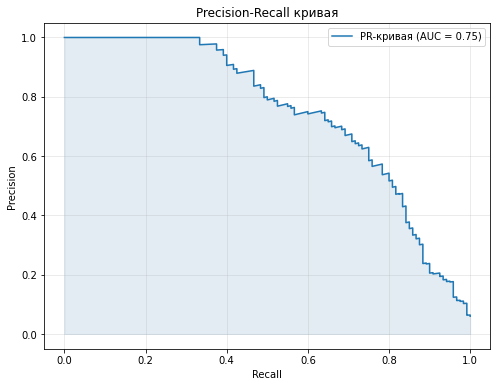

In [66]:
#График
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR-кривая (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)
plt.fill_between(recall, precision, alpha=0.15, color='steelblue')
plt.title('Precision-Recall кривая')
plt.legend()
plt.show()

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

Финальная модель — это пайплайн, включающий ColumnTransformer с числовым препроцессингом (SimpleImputer со стратегией median и RobustScaler) и категориальным (SimpleImputer со стратегией most_frequent и OneHotEncoder с handle_unknown ignore), а также LogisticRegression с параметрами C 0.1, penalty l1, saga, class_weight none, random_state 42 и max_iter 1000. Обучение и оценка проводились на отложенной тестовой выборке в 20 процентов данных со stratify по целевой переменной, а подбор гиперпараметров и отбор признаков — только на X_train через StratifiedKFold с 10 фолдами. Итоговые метрики: PR AUC на кросс-валидации 0.7095, PR AUC на тесте 0.7478. PR AUC на тесте оказался выше, чем на кросс-валидации, что говорит об отсутствии переобучения и хорошем обобщении модели. На метрики повлияло несколько факторов. Главный источник прироста — новые признаки: базовый PR AUC логистической регрессии без них составлял 0.58, а после добавления пяти признаков вырос до 0.66. Наибольший вклад дали app_crashes_last_month_squared с коэффициентом плюс 2.03, sqrt_app_opens_per_week с плюс 1.79, sqrt_days_since_last_promo с плюс 0.57 и sqrt_total_spent_last_month с минус 0.48, тогда как activity с плюс 0.03 оказался почти нулевым и не дал нового сигнала. Второй фактор — подбор гиперпараметров с помощью GridSearch. Третий фактор — удаление geo_location: признак с высокой кардинальностью в 80 с лишним регионов доминировал в коэффициентах, но не давал прироста, и после удаления метрика даже незначительно улучшилась, что подтверждает правило, что высокая кардинальность не равна пользе. Четвёртый фактор — удаление слабых признаков 'seasons', 'days_since_last_order','activity', 'total_spent_last_month', 'notifications_enabled', 'coffee_preference_change', 'discount_usage_rate','review_rating_last_1', которые имели коэффициент по модулю меньше 0.09 или дублировали другие; это не ухудшило метрику, но сделало модель проще и интерпретируемее. Пятый фактор — использование StratifiedKFold вместо обычного KFold, что критично при дисбалансе 94 на 6, поскольку стратификация сохраняет пропорцию классов в каждом фолде и даёт стабильные сопоставимые метрики. Наиболее важные факторы — это новые признаки, давшие плюс 0.18 к PR AUC, оптимальный гиперпараметры, удаление geo_location, использование StratifiedKFold. Финальная модель показала PR AUC 0.748 на тестовой выборке, что является отличным результатом для задачи оттока с дисбалансом 94 на 6. Модель сохранена в churn_pipeline.pkl и готова к внедрению.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [67]:
joblib.dump(best_pipeline, 'churn_pipeline.pkl')

['churn_pipeline.pkl']

In [68]:
loaded_pipeline = joblib.load('churn_pipeline.pkl')
print(loaded_pipeline)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['order_frequency_week',
                                                   'avg_order_value',
                                                   'seasonal_menu_tried',
                                                   'app_opens_per_week',
                                                   'review_rating_last_10',
                                                   'app_crashes_last_month',
                                                   'days_since_last_promo',
                                             

In [69]:
y_proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]
pr_auc_loaded = average_precision_score(y_test, y_proba_loaded)
print(f"PR AUC (loaded): {pr_auc_loaded:.4f}")

PR AUC (loaded): 0.7478
